In [1]:
import numpy as np
import pandas as pd
import requests
import io



url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'

response = requests.get(url)

if response.status_code == 200:
    print('Download completed')
    df = pd.read_csv(io.StringIO(response.text))
else:
    print('Download failed. Status code: {response.status_code}')


Download completed


In [2]:
# df
# df.info()
df = df.drop(columns=['Unnamed: 0'])
# df['item_id'].duplicated().any()
df = df.drop_duplicates(subset=['item_id']).copy()
# df['item_id'].duplicated().any()

In [3]:
print(df.head())

    item_id                   name       category   price     old_price  \
0  90420332               FREKVENS  Bar furniture   265.0  No old price   
1    368814              NORDVIKEN  Bar furniture   995.0  No old price   
2   9333523  NORDVIKEN / NORDVIKEN  Bar furniture  2095.0  No old price   
3  80155205                   STIG  Bar furniture    69.0  No old price   
4  30180504                NORBERG  Bar furniture   225.0  No old price   

   sellable_online                                               link  \
0             True  https://www.ikea.com/sa/en/p/frekvens-bar-tabl...   
1            False  https://www.ikea.com/sa/en/p/nordviken-bar-tab...   
2            False  https://www.ikea.com/sa/en/p/nordviken-nordvik...   
3             True  https://www.ikea.com/sa/en/p/stig-bar-stool-wi...   
4             True  https://www.ikea.com/sa/en/p/norberg-wall-moun...   

  other_colors                                  short_description  \
0           No           Bar table, in/ou

In [4]:
df['designer'].value_counts()

df.loc[:, 'designer'] = df['designer'].astype(str)
df.loc[:,'designer'] = df['designer'].str.replace(r'[\n\r]',' ', regex=True)
df.loc[:, 'designer'] = df['designer'].str.replace(r'\s+',' ', regex=True).str.strip()
df['designer'] = df['designer'].apply(lambda x: 'IKEA of Sweden' if pd.isna(x) or any(char.isdigit() for char in str(x)) else x)

mask = df['designer'].str.match(r'^[\d\.\s]+$')
df.loc[mask, 'designer'] = 'Unknown Designer'
df.loc[df['designer'] == 'nan', 'designer'] = 'Unknown Designer'
print(df['designer'].value_counts().head(70))

designer
IKEA of Sweden                       785
Ehlén Johansson                      136
Francis Cayouette                    131
Ola Wihlborg                         128
Jon Karlsson                         106
                                    ... 
Francis Cayouette/Ehlén Johansson      7
Nicholai Wiig Hansen                   6
IKEA of Sweden/Carl Öjerstam           6
A Fredriksson/J Hultqvist/W Chong      6
Lisa Hilland                           6
Name: count, Length: 70, dtype: int64


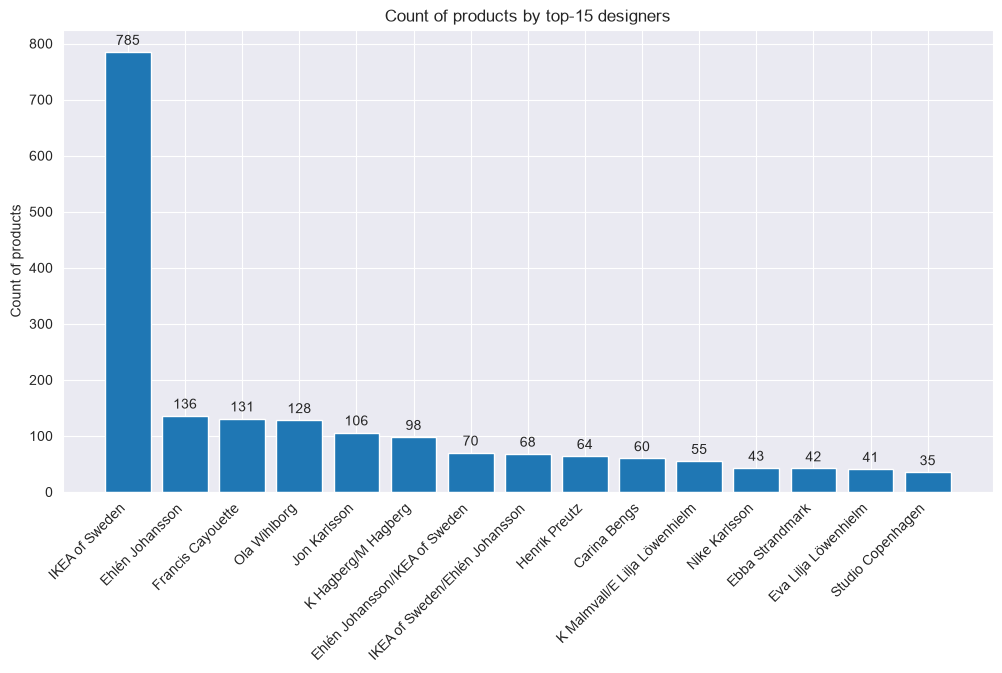

In [5]:


import matplotlib.pyplot as plt
import seaborn as sns

top_designers = df['designer'].value_counts().head(15)

fig, ax = plt.subplots(figsize = (12,6))
bars = ax.bar(top_designers.index, top_designers.values)
ax.bar_label(bars, padding=3)

plt.xticks(rotation=45, ha='right')
plt.title('Count of products by top-15 designers')
plt.ylabel('Count of products');



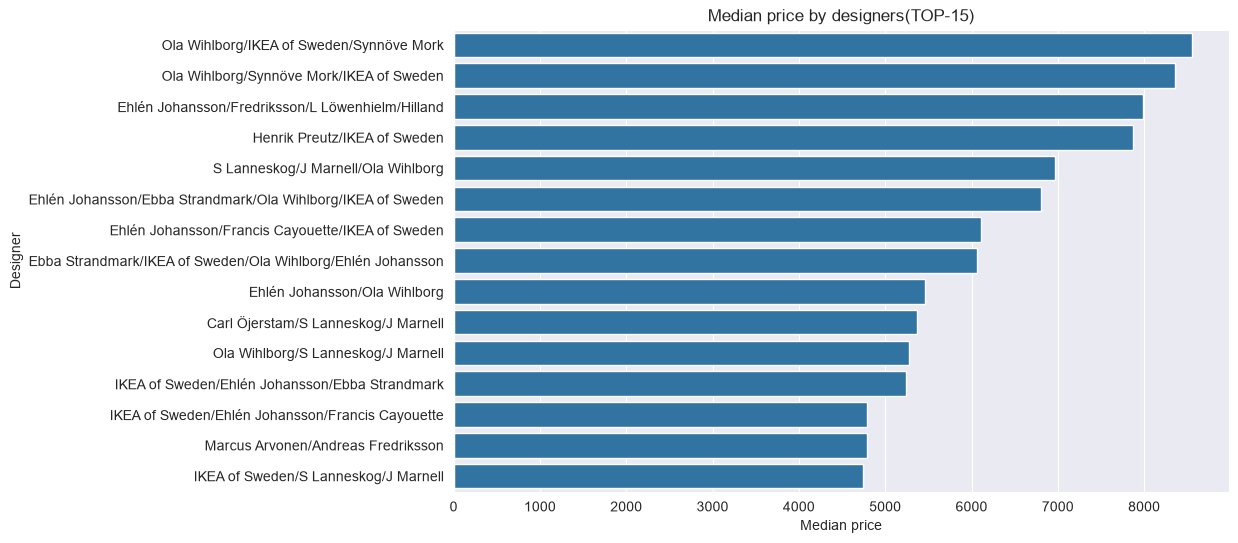

In [6]:

plt.figure(figsize=(10,6))

designer_median = df.groupby(by = 'designer')['price'].median().sort_values(ascending = False).head(15)

sns.barplot(
    x = designer_median.values,
    y = designer_median.index
)

plt.title('Median price by designers(TOP-15)')
plt.xlabel('Median price')
plt.ylabel('Designer');




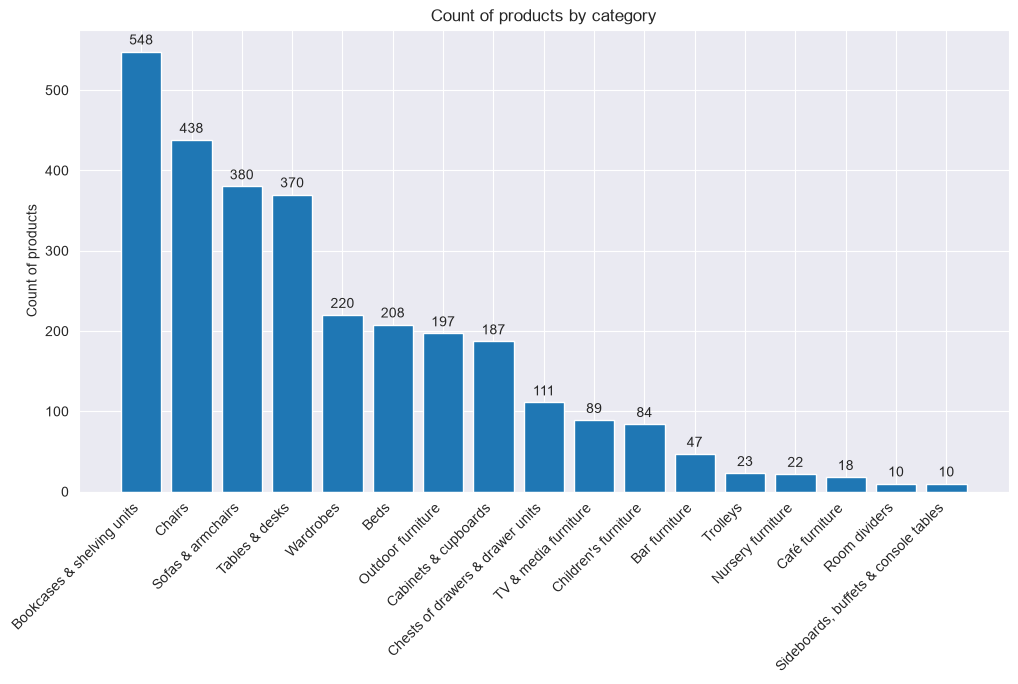

In [7]:
cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize = (12,6))
bars = ax.bar(cat_counts.index, cat_counts.values)
ax.bar_label(bars, padding=3)

plt.xticks(rotation=45, ha='right')
plt.title('Count of products by category')
plt.ylabel('Count of products');


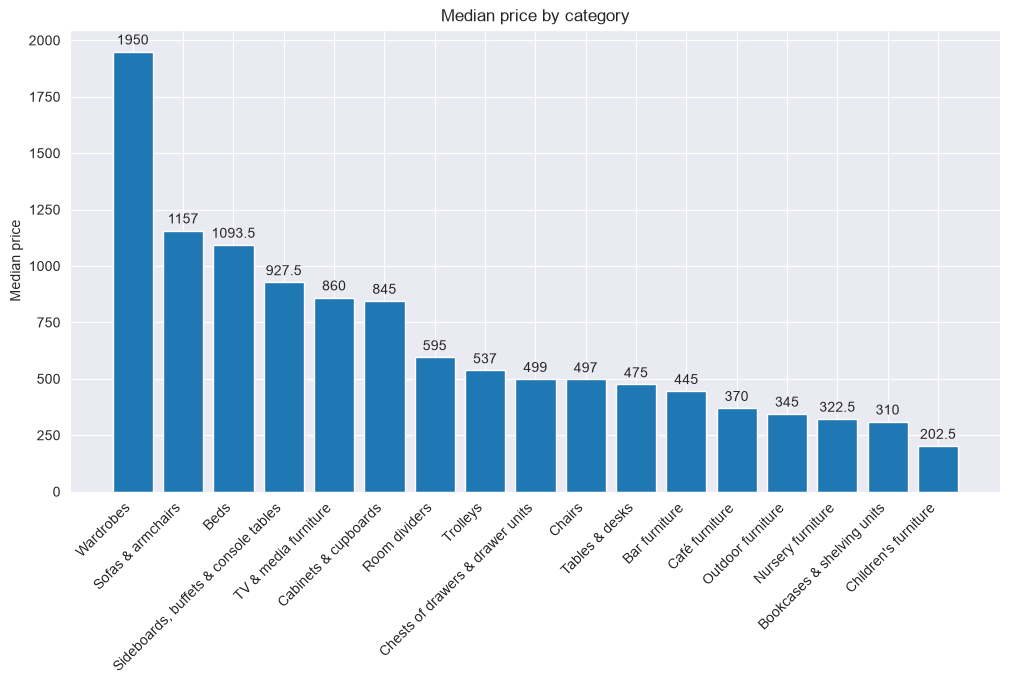

In [8]:
cat_median_price = df.groupby( by = 'category')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize = (12,6))
bars = ax.bar(cat_median_price.index, cat_median_price.values)
ax.bar_label(bars, padding=3)

plt.xticks(rotation=45, ha='right')
plt.title('Median price by category')
plt.ylabel('Median price') ;


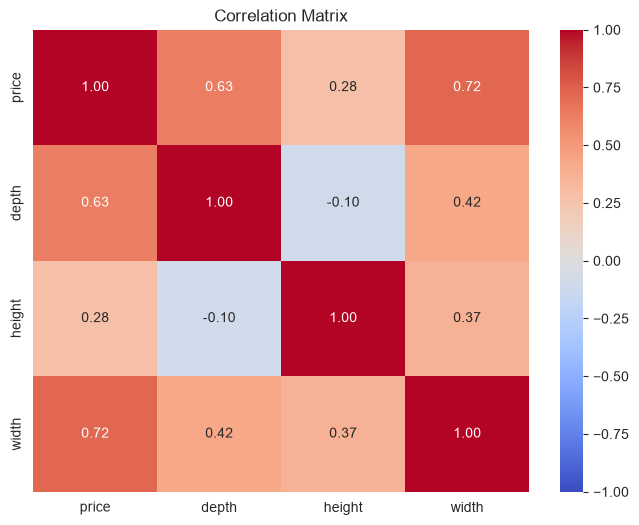

In [9]:
df['price'].isna().any()

corr_cols = ['price', 'depth', 'height', 'width']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot= True,
    cmap= 'coolwarm',
    fmt = '.2f',
    vmin= -1,
    vmax=1,
)

plt.title('Correlation Matrix');



In [10]:
df['old_price'] = df['old_price'].replace(r'[^\d.]', '', regex=True)

df['old_price'] = pd.to_numeric(df['old_price'], errors='coerce')
df['old_price']
# тут не меняю наши nan на медианные или текущие цены, потому что это испортит нам
# всю наглядность графика



0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
         ...  
3688       NaN
3689     820.0
3690    1755.0
3691    1050.0
3692    3130.0
Name: old_price, Length: 2962, dtype: float64

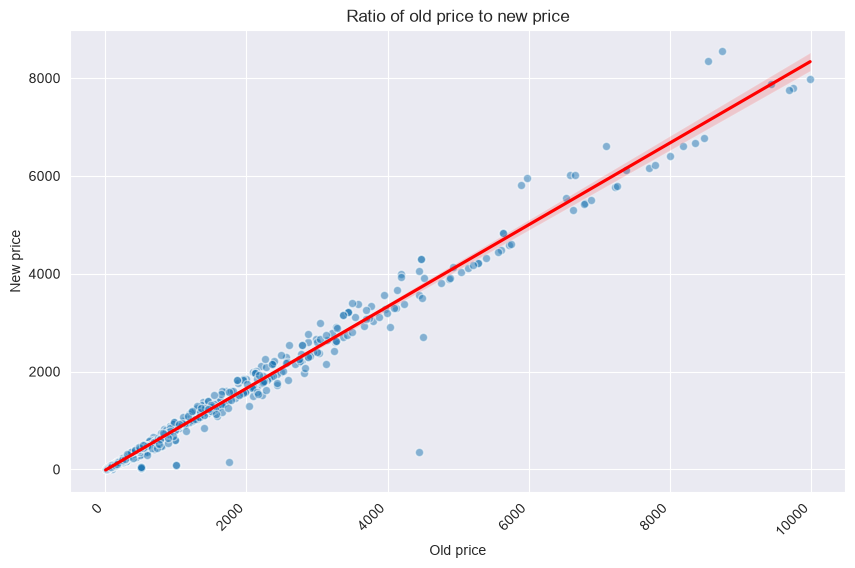

In [11]:
fig, ax = plt.subplots(figsize= (10,6))

sns.regplot(
    data=df,
    x='old_price',
    y='price',
    line_kws={'color':'red'},
    scatter_kws={'alpha' : 0.5, 'edgecolor' : 'w' }
)

plt.title('Ratio of old price to new price')
plt.xlabel('Old price')
plt.ylabel('New price')
plt.xticks(rotation=45, ha='right');


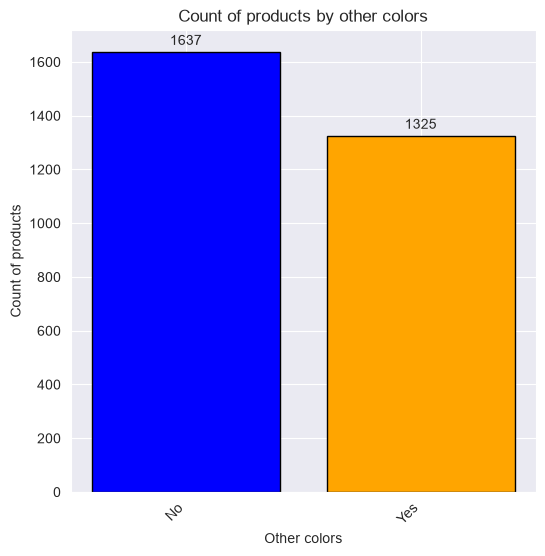

In [12]:
colors_count = df['other_colors'].value_counts()

fig, ax = plt.subplots(figsize= (6,6))

bars= ax.bar(colors_count.index, colors_count.values, edgecolor= 'black', color=['blue', 'orange'])
ax.bar_label(bars, padding=3)
plt.xticks(rotation=45, ha='right')
plt.title('Count of products by other colors')
plt.ylabel('Count of products')
plt.xlabel('Other colors');


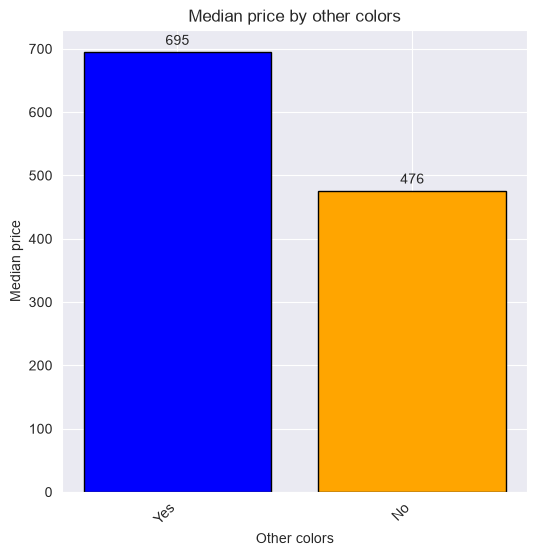

In [13]:
colors_median = df.groupby(by = 'other_colors')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize= (6,6))

bars = ax.bar(colors_median.index, colors_median.values, edgecolor= 'black', color=['blue', 'orange'] )
ax.bar_label(bars, padding=3)

plt.title('Median price by other colors')
plt.ylabel('Median price')
plt.xlabel('Other colors')
plt.xticks(rotation=45, ha='right');


# по этим двум графиками можем сделать вывод, что палитка разнообразия цветов влияет на цены продуктов.
# У продуктов что имеют разные цвета цена выше, и наоборот у продуктов со скудной палитрой цена ниже.

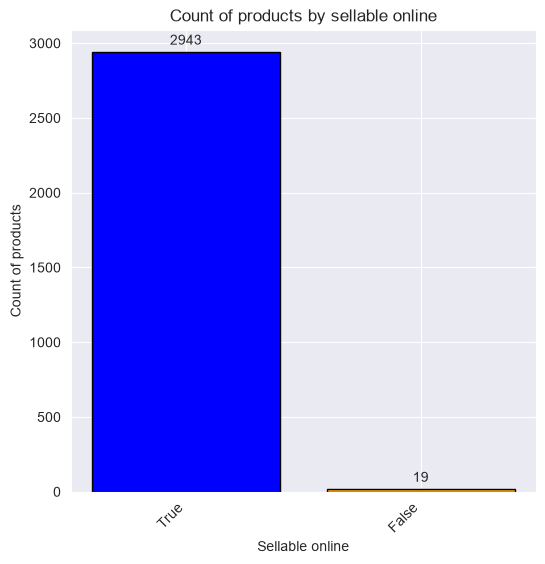

In [14]:
online_count = df['sellable_online'].astype(str).value_counts()

fig, ax = plt.subplots(figsize= (6,6))
bars = ax.bar(online_count.index, online_count.values, edgecolor= 'black', color=['blue', 'orange'] )
ax.bar_label(bars, padding=3)

plt.xticks(rotation=45, ha='right')
plt.title('Count of products by sellable online')
plt.ylabel('Count of products')
plt.xlabel('Sellable online');


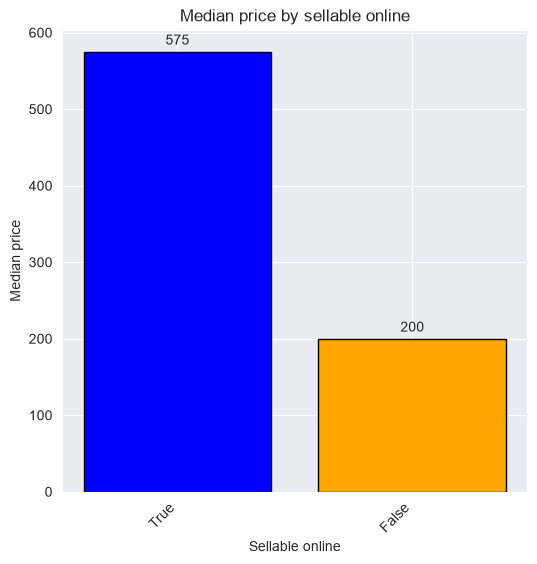

In [15]:
online_median = df.groupby(by = 'sellable_online')['price'].median().sort_values(ascending=False)
online_median.index = online_median.index.astype(str)

fig , ax = plt.subplots(figsize= (6,6))
bars=  ax.bar(online_median.index, online_median.values, edgecolor= 'black', color=['blue', 'orange'] )
ax.bar_label(bars, padding=3)
plt.xticks(rotation=45, ha='right')
plt.title('Median price by sellable online')
plt.ylabel('Median price')
plt.xlabel('Sellable online');


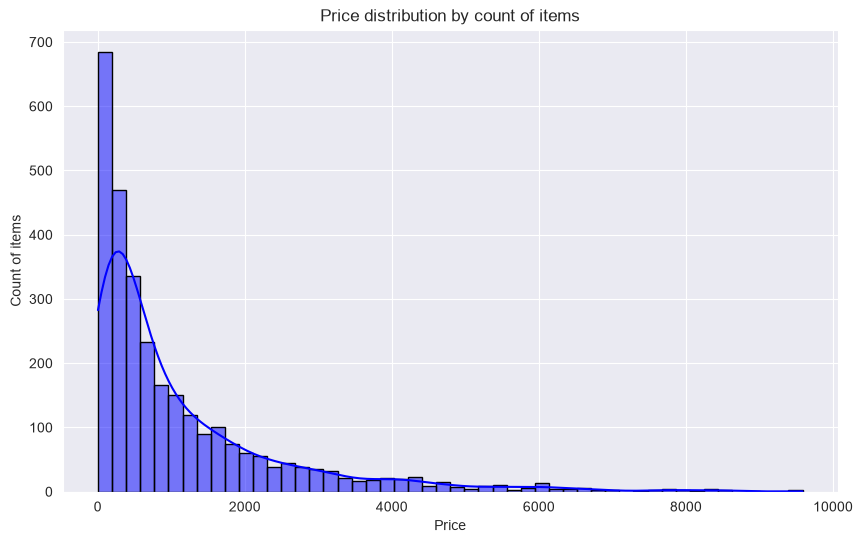

In [16]:
fig , ax = plt.subplots(figsize= (10,6))

sns.histplot(
    data=df,
    x='price',
    bins=50,
    kde=True,
    color='blue',
    edgecolor='black',
)

plt.title('Price distribution by count of items')
plt.ylabel('Count of items')
plt.xlabel('Price');

In [17]:
#                                                                                                     UA version
# Загальні висновки з описової статистики (EDA):
#
# Аналізуючи побудовані візуалізації, можна зробити наступні висновки щодо бізнес-моделі та асортименту IKEA:
#

# Цінова політика та структура асортименту (Гістограма):
#
# Розподіл цін має яскраво виражену правосторонню асиметрію . Це підтверджує головну стратегію компанії: основу асортименту складають недорогі товари масового вжитку , тоді як дорогий преміум-сегмент представлений у значно меншій кількості (довгий "хвіст" графіка).
#
#
#
# Вплив кастомізації на ціну (Графіки кольорів):
#
# Гіпотеза щодо того, що товари з вибором кольорів коштують дорожче, підтвердилася. Медіанна ціна товарів з альтернативними кольорами значно вища (695 проти 476). Це пояснюється тим, що дешеві базові речі часто випускаються в одному універсальному кольорі для здешевлення виробництва, тоді як дорогі товари потребують кастомізації під інтер'єр клієнта.
#
#
#
# Онлайн-комерція (Sellable online):
#
# IKEA практично повністю диджиталізувала свої продажі — понад 99% каталогу (2943 позиції) доступні для замовлення онлайн. Мізерна частка товарів (лише 19 одиниць), що продаються виключно в офлайн-магазинах, найімовірніше, належить до специфічних категорій (наприклад, живі рослини, продукти харчування або надзвичайно крихкі скляні вироби).
#
#
#
# Дизайн та авторство:
#
# Абсолютним лідером за кількістю розроблених товарів є команда «IKEA of Sweden». Компанія робить ставку на власний корпоративний дизайн, а залучення сторонніх іменитих дизайнерів використовується переважно для лімітованих колекцій.
#
#
#
# Політика знижок (Лінія регресії):
#
# Аналіз співвідношення old_price та price показав чітку лінійну залежність. Точки щільно прилягають до лінії тренду, що свідчить про використання стабільних, пропорційних знижок без радикальних "ліквідаційних" розпродажів (зниження цін відбувається плавно та прогнозовано).





In [18]:
#                                                                                                        ENG version
# General conclusions from Exploratory Data Analysis (EDA):
#
# Based on the generated visualizations, the following conclusions can be drawn regarding IKEA's business model and product range:
#

# Pricing policy and product range structure (Histogram):
#
# The price distribution exhibits a pronounced right skew. This confirms the company's core strategy: the product range consists primarily of affordable, mass-market goods, while the high-end premium segment is represented in significantly smaller numbers (indicated by the long "tail" of the graph).
#
#
#
# Impact of customization on price (Color charts):
#
# The hypothesis that products offering color choices cost more has been confirmed. The median price of products with alternative color options is significantly higher (695 vs. 476). This is because inexpensive, basic items are often produced in a single, universal color to reduce manufacturing costs, whereas higher-end products require customization to suit the customer's interior.
#
#
#
# Online Commerce (Sellable online):
#
# IKEA has digitized its sales almost entirely—over 99% of its catalog (2,943 items) is available for online ordering. The negligible fraction of products (only 19 items) sold exclusively in physical stores likely falls into specific categories (such as live plants, food products, or extremely fragile glassware).
#
#
#
# Design and Authorship:
#
# The "IKEA of Sweden" team is the clear leader in terms of the number of products developed. The company focuses on its own in-house design, while collaborations with renowned external designers are primarily reserved for limited-edition collections.
#
#
#
# Discount Policy (Regression Line):
#
# Analysis of the relationship between `old_price` and `price` revealed a clear linear dependency. The data points cluster tightly around the trend line, indicating the use of consistent, proportional discounts rather than drastic "liquidation" sales (price reductions occur smoothly and predictably).

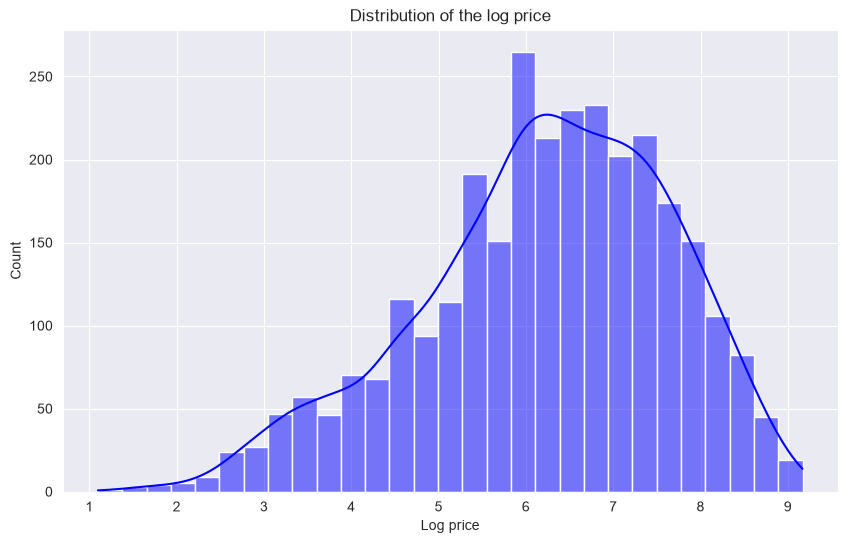

In [19]:
from scipy import stats
import numpy as np

df['price_ln'] = np.log(df['price'])

fig, ax = plt.subplots(figsize= (10,6))
sns.histplot(
    df['price_ln'],
    kde=True,
    color='blue',
)

plt.title('Distribution of the log price')
plt.xlabel('Log price')
plt.ylabel('Count');



In [20]:
group_colors_yes = df[df['other_colors'] == 'Yes']['price_ln'].dropna()
group_colors_no = df[df['other_colors'] == 'No']['price_ln'].dropna()

print('Hypothesis 1: The impact of color choice on price')

t_stat, p_val_t = stats.ttest_ind(group_colors_yes, group_colors_no, equal_var=False)
print(f'1. T-test p-value: {p_val_t:.5f}')

u_stat, p_val_u = stats.mannwhitneyu(group_colors_yes, group_colors_no, alternative='two-sided')
print(f'2. Mann-Whitney U-test p-value: {p_val_u:.5f}')

if p_val_t < 0.05:
    print('Conclusion: We discard the hypothesis H0. The prices difference in prices is statistically significant.')
else:
    print('Conclusion: There are no grounds to reject H0. The difference is not statistically significant.')



Hypothesis 1: The impact of color choice on price
1. T-test p-value: 0.00000
2. Mann-Whitney U-test p-value: 0.00000
Conclusion: We discard the hypothesis H0. The prices difference in prices is statistically significant.


In [21]:
group_ikea_design = df[df['designer'] == 'IKEA of Sweden']['price_ln'].dropna()
group_other_design = df[df['designer'] != 'IKEA of Sweden']['price_ln'].dropna()

print('Hypothesis: 2: Designer impact (IKEA of Sweden) on price')

t_stat2, p_val_t2 = stats.ttest_ind(group_ikea_design, group_other_design, equal_var=False)
print(f'1. T-test p-value: {p_val_t2:.5f}')

u_stat2, p_val_u2 = stats.mannwhitneyu(group_ikea_design, group_other_design, alternative='two-sided')
print(f'2. Mann-Whitney U-test p-value: {p_val_u2:.5f}')

if p_val_t2 < 0.05:
    print('Conclusion: We discard the hypothesis H0. The designer really influences on pricing')
else:
    print('Conclusion: There are no grounds to reject H0. Pricing does not depend on the designer.')

Hypothesis: 2: Designer impact (IKEA of Sweden) on price
1. T-test p-value: 0.00000
2. Mann-Whitney U-test p-value: 0.00000
Conclusion: We discard the hypothesis H0. The designer really influences on pricing


In [22]:
#                                                                                                     UA version

# Для проведення статистичного аналізу дані про ціни (price) були попередньо логарифмовані (price_ln). Це дозволило нормалізувати розподіл (мінімізувати вплив різких цінових викидів у преміум-сегменті) та зробити результати статистичних тестів надійними.
#
#
# Для перевірки гіпотез використовувалися два різні критерії:
#
# Параметричний: T-тест Уелча (T-test)
# Непараметричний: Критерій Манна-Уїтні (Mann-Whitney U-test)
#
#
# Гіпотеза 1: Вплив наявності різних кольорів на ціну
#
# H0 (Нульова гіпотеза): Середня ціна товарів з вибором кольорів та без нього не відрізняється.
# H1 (Альтернативна гіпотеза): Ціни на ці дві групи товарів статистично значущо відрізняються.
# Результат: Обидва тести показали p-value < 0.05 (p-value = 0.0).
#
# Висновок: Відхиляємо H0. Товари, що мають альтернативні варіанти кольорів, статистично значущо дорожчі за товари, що випускаються лише в одному базовому кольорі.
#
#
#
# Гіпотеза 2: Вплив розробника (IKEA of Sweden vs інші дизайнери) на ціноутворення
#
# H0 (Нульова гіпотеза): Середня ціна товарів, розроблених командою «IKEA of Sweden», не відрізняється від ціни товарів інших авторів.
# H1 (Альтернативна гіпотеза): Існує статистично значуща різниця в цінах залежно від дизайнера.
# Результат: Обидва тести показали p-value < 0.05 (p-value = 0.0).
#
# Висновок: Відхиляємо H0. Авторство дизайну має статистично значущий вплив на ціну товару. Залучення зовнішніх дизайнерів або специфічні авторські колекції формують інший ціновий сегмент порівняно з базовим корпоративним дизайном.

In [23]:
#                                                                                                      ENG version

# For the statistical analysis, the price data were logarithmically transformed (price_ln). This allowed for the normalization of the distribution (minimizing the impact of extreme price outliers in the premium segment) and ensured the reliability of the statistical test results.
#
#
# Two different tests were used to verify the hypotheses:
#
# Parametric: Welch's t-test
# Non-parametric: Mann-Whitney U-test
#
#
# Hypothesis 1: Impact of color variety on price
#
# H0 (Null hypothesis): There is no difference in the average price between products with color options and those without.
# H1 (Alternative hypothesis): The prices of these two groups of products differ in a statistically significant way.
# Result: Both tests yielded a p-value < 0.05 (p-value = 0.0).
#
# Conclusion: We reject H0. Products with color options are statistically significantly more expensive than products available in only a single basic color.
#
#
#
# Hypothesis 2: The impact of the designer (IKEA of Sweden vs. other designers) on pricing
#
# H0 (Null hypothesis): The average price of products designed by the "IKEA of Sweden" team does not differ from the price of products by other designers.
# H1 (Alternative hypothesis): There is a statistically significant difference in prices depending on the designer.
# Result: Both tests yielded a p-value < 0.05 (p-value = 0.0).
#
# Conclusion: We reject H0. The designer has a statistically significant impact on the product price. The involvement of external designers or specific designer collections creates a different price segment compared to the standard corporate design.

               Model  R2_score        RMSE
2      Random Forest  0.826016  572.450787
3  Gradient Boosting  0.793972  622.940258
1      Decision Tree  0.748027  688.906007
0  Linear Regression  0.703911  746.782375


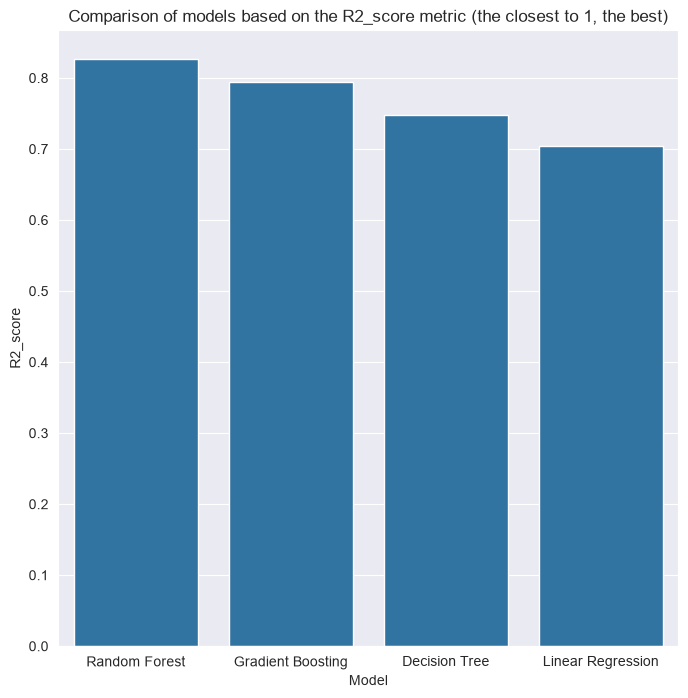

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

designer_medians = df.groupby(by = 'designer')['price'].median()
category_median = df.groupby(by = 'category')['price'].median()

df['designer_encoded'] = df['designer'].map(designer_medians)
df['category_encoded'] = df['category'].map(category_median)


cols_to_drop = ['price', 'old_price', 'sellable_online', 'item_id', 'link', 'name', 'price_ln', 'short_description', 'designer', 'category']

X = df.drop(columns = cols_to_drop)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['depth', 'height', 'width', 'designer_encoded', 'category_encoded']
categorical_features = ['other_colors']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
        ('onehot' , OneHotEncoder(handle_unknown='ignore'))
          ])

preprocessor = ColumnTransformer(
    transformers=[
        ('num' , numeric_transformer, numeric_features),
        ('cat' , categorical_transformer, categorical_features),
    ])

models= {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    r2 = metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

    results.append({'Model': name, 'R2_score': r2, 'RMSE': rmse})

results_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False)
print(results_df)

plt.figure(figsize=(8,8))
sns.barplot(
    data=results_df,
    x='Model',
    y='R2_score',
)

plt.title('Comparison of models based on the R2_score metric (the closest to 1, the best)')
plt.xlabel('Model')
plt.ylabel('R2_score');


best params: {'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
R2_score after grid search: 0.84510
------Impact of factors on price------


,Importance %
width,36.240900
designer,27.955512
depth,16.692873
height,9.327494
category,8.094970
other_colors,1.688251


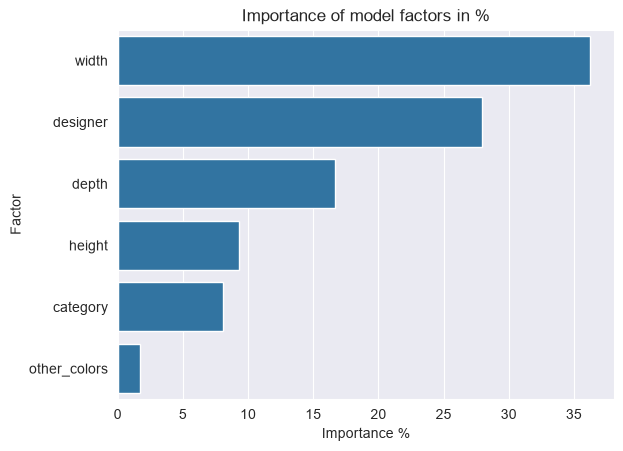

In [26]:
from sklearn.model_selection import GridSearchCV, cross_val_score

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42)),
])

param_grid = {
    'model__n_estimators': [100,200],
    'model__max_depth': [15,20,25],
    'model__max_features': ['sqrt','log2', 1.0],
}

grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, n_jobs=-1, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f'best params: {grid_search.best_params_}')
print(f'R2_score after grid search: {best_model.score(X_test, y_test):.5f}')


feature_importances = best_model.named_steps['model'].feature_importances_

cat_columns = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

final_columns = np.concatenate([numeric_features,cat_columns])

importance_df = pd.DataFrame({
    'Feature': final_columns,
    'Importance': feature_importances
})

base_features = ['category', 'designer', 'other_colors', 'depth', 'height', 'width']
grouped_importances = {key: 0.0 for key in base_features}

for _, row in importance_df.iterrows():
    for key in grouped_importances:
        if row ['Feature'].startswith(key):
            grouped_importances[key] += row['Importance']
            break

grouped_df = pd.DataFrame.from_dict(grouped_importances, orient='index', columns = ['Importance'])
grouped_df['Importance %'] = (grouped_df['Importance'] / grouped_df['Importance'].sum()) * 100
grouped_df = grouped_df.sort_values(by = 'Importance %', ascending = False)

print('------Impact of factors on price------')
display(grouped_df[['Importance %']])

sns.barplot(
    x= grouped_df['Importance %'],
    y= grouped_df.index,
)

plt.title('Importance of model factors in %')
plt.xlabel('Importance %')
plt.ylabel('Factor');



---start of cross validation---
R2_scores on 5 folds: [0.8299 0.8414 0.8459 0.7838 0.8567]
Average R2_score (cross-validation): 0.83154


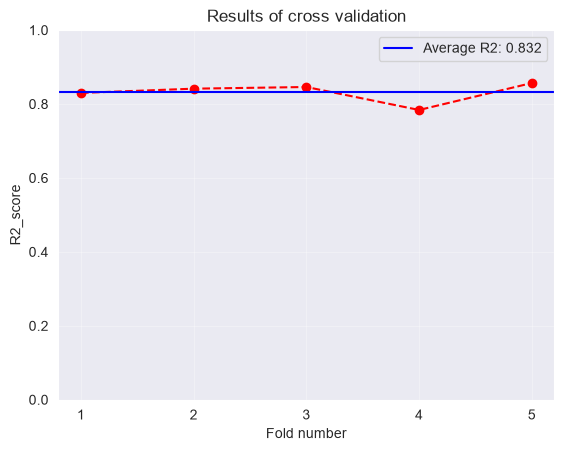

In [27]:
print('---start of cross validation---')
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print(f'R2_scores on 5 folds: {np.round(cv_scores, 4)}')
print(f'Average R2_score (cross-validation): {cv_scores.mean():.5f}')

plt.plot(range(1,6), cv_scores, marker = 'o', linestyle = '--', color = 'red')
plt.axhline(y=cv_scores.mean(), color = 'blue', linestyle = '-', label = f'Average R2: {cv_scores.mean():.3f}')
plt.title('Results of cross validation')
plt.xlabel('Fold number')
plt.ylabel('R2_score')
plt.legend()
plt.ylim(0,1)
plt.xticks(range(1,6))
plt.grid(True, alpha= 0.3);

In [58]:
                                                                                                       # UA version
#       Висновки:
#
# З набору ознак виключено змінні, що спричиняють мультиколінеарність (old_price), не несуть прогностичної цінності (sellable_online, item_id, link) або мають надто високу кардинальність (short_description). Пропуски в числових габаритах заповнено медіаною. Для оптимізації роботи з категоріальними ознаками високої кардинальності (designer, category) було застосовано метод Target Median Encoding , а для лінійних моделей додано масштабування StandardScaler.
#
# Серед чотирьох протестованих алгоритмів найкращий результат на тестовій вибірці показала модель Random Forest (R2 Score ~ 0.83).
#
# За допомогою GridSearchCV було підібрано оптимальні налаштування (обмеження глибини дерев max_depth та використання max_features), що покращило точність прогнозування.
#
#
#       Аналіз впливу факторів (Feature Importance):
#
# Габарити (сумарно понад 62%): Фізичні розміри товару (ширина ~34.5%, глибина ~16.9%, висота ~10.7%) є головним фактором ціноутворення. Більше витрачених матеріалів закономірно призводить до вищої вартості.
#
# Дизайнер (~24.5%): Ім'я розробника вносить майже чверть вкладу у вартість. Це повністю підтверджує нашу статистичну гіпотезу з третього розділу про те, що авторські колекції формують інший ціновий сегмент порівняно з базовим дизайном.
#
# Категорія (~11.1%) та Колір (~2%): Мають значно менший вплив на алгоритм прогнозування в межах наявних даних.
#
#
#       Крос-валідація та вплив викидів:
#
# Для коректної оцінки стабільності моделі та уникнення витоку інформації крос-валідацію (cv=5) було проведено виключно на X_train.
# Результати показали високу стабільність алгоритму: середній показник R2_score склав ~0.831, без критичних провалів на жодному з фолдів.
#
#
#     Загальний Підсумок:
#
# Завдяки використанню методу Target Median Encoding для складних категоріальних ознак та усуненню витоку даних під час валідації, фінальна модель Random Forest показала високу стабільність та точність (R2 ~ 0.83). Побудована модель успішно справляється з ціновими викидами і точно виявляє ключові патерни ціноутворення IKEA всього асортименту.
# Для подальшого покращення прогностичної здатності найліпшим кроком буде збагачення датасету інформацією про матеріали виготовлення меблів (оскільки, наприклад, натуральне дерево та пластик за однакових габаритів мають різну вартість).

In [59]:
#                                                                                                      ENG version
#       Conclusions:
#
# Variables causing multicollinearity (old_price), lacking predictive value (sellable_online, item_id, link), or having excessively high cardinality (short_description) were excluded from the feature set. Missing values in numerical dimensions were imputed using the median. To optimize the handling of high-cardinality categorical features (designer, category), the Target Median Encoding method was applied, and StandardScaler scaling was added for linear models.
#
# Among the four tested algorithms, the Random Forest model demonstrated the best performance on the test set (R2 Score ~ 0.83).
#
# Optimal settings were identified using GridSearchCV (specifically, limiting tree depth via max_depth and using max_features), which improved prediction accuracy.
#
#
#       Feature Importance Analysis:
#
# Dimensions (over 62% in total): The physical size of the product (width ~34.5%, depth ~16.9%, height ~10.7%) is the primary pricing factor. Naturally, greater material usage leads to a higher cost.
#
# Designer (~24.5%): The designer's name contributes nearly a quarter to the value. This fully confirms our statistical hypothesis from the third section that signature collections form a different price segment compared to the base design.
#
# Category (~11.1%) and Color (~2%): These have a significantly smaller impact on the prediction algorithm within the available data.
#
#
#       Cross-Validation and the Impact of Outliers:
#
# To accurately assess model stability and prevent data leakage, cross-validation (cv=5) was performed strictly on X_train.
# The results demonstrated high algorithmic stability: the average R2_score was ~0.831, with no critical drops on any of the folds.
#
#
#     General Conclusion:
#
# Thanks to the use of the Target Median Encoding method for complex categorical features and the elimination of data leakage during validation, the final Random Forest model demonstrated high stability and accuracy (R2 ~ 0.83). The built model successfully handles price outliers and accurately identifies key IKEA pricing patterns across the entire assortment.
# To further improve predictive capability, the best next step would be enriching the dataset with information about furniture manufacturing materials (since, for example, natural wood and plastic have different costs for the same dimensions).